In [1]:

import os, sys
import json
import pickle
import pandas as pd
from pathlib import Path

# notebooks/ から見た src のパスを追加
sys.path.append(os.path.abspath("../src"))

from sim_utils import *

def load_simulation_data(sim_dir_path):
    root = Path(sim_dir_path)
    data = {
        "config": {},
        "landscape": {},
        "stimuli": {}
    }

    # --- 1. Config フォルダのロード ---
    config_dir = root / "config"
    if config_dir.exists():
        # JSON
        json_path = config_dir / "config.json"
        if json_path.exists():
            data["config"]["config_json"] = json.loads(json_path.read_text())

        # Pickle系 (クラス定義変更に強い順にトライ)
        pkl_files = {
            "robot": "robot.pkl",
            "agent": "agent.pkl",
            "const_beliefs": "const_beliefs_result.pkl",
            "optimizer_state": "optimizer_state.pkl",
            "used_optimizer": "used_optimizer.pkl"
        }

        for key, file_name in pkl_files.items():
            file_path = config_dir / file_name
            if file_path.exists():
                try:
                    with open(file_path, 'rb') as f:
                        data["config"][key] = pickle.load(f)
                except (AttributeError, ImportError, ModuleNotFoundError) as e:
                    print(f"⚠️ Warning: {file_name} のロードに失敗しました (クラス定義の変更が原因かもしれません): {e}")
                    data["config"][key] = None

    # --- 2. Landscape フォルダのロード ---
    landscape_dir = root / "landscape"
    if landscape_dir.exists():
        # CSV
        csv_path = landscape_dir / "simulation_results.csv"
        if csv_path.exists():
            data["landscape"]["df"] = pd.read_csv(csv_path)

        # Raw Data (Pickle)
        raw_path = landscape_dir / "raw_data.pkl"
        if raw_path.exists():
            with open(raw_path, 'rb') as f:
                data["landscape"]["raw_data"] = pickle.load(f)

    # --- 3. Stimuli フォルダのロード (サブフォルダ含む) ---
    stimuli_dir = root / "stimuli"
    if stimuli_dir.exists():
        for sub_dir in stimuli_dir.iterdir():
            if sub_dir.is_dir():
                target_json = sub_dir / "target.json"
                if target_json.exists():
                    data["stimuli"][sub_dir.name] = json.loads(target_json.read_text())

    return data

# 実行
# sim_dir = "./path_to_your_sim_result"
# results = load_simulation_data(sim_dir)

<h>保存したシミュレーション環境を再現</h>

In [48]:
%load_ext autoreload
%autoreload 2
from sim_utils import Optimizer
import inspect


sim_dir = Path("/home/rikut/py_venvs/my_sim_project/results/sim_dof2_20251215_213121")
results = load_simulation_data(sim_dir)

# --- Config 関連 ---
config_json = results["config"].get("config_json")
robot = results["config"].get("robot")
agent = results["config"].get("agent")
env = results["config"].get("env")
const_beliefs_result = results["config"].get("const_beliefs")
optimizer_state = results["config"].get("optimizer_state")

# --- Optimizer の再構築 ---
if optimizer_state is not None:
    # 1. Optimizer.__init__ が受け取れる引数リストを取得
    sig = inspect.signature(Optimizer.__init__)
    valid_keys = sig.parameters.keys() # ['self', 'robot', 'agent', 'timesteps', ...]

    # 2. optimizer_state から、__init__ に渡せる有効なデータだけを抽出
    # ただし 'robot' と 'agent' は既に別途ロードしているので、そちらを優先する
    init_params = {
        k: v for k, v in optimizer_state.items() 
        if k in valid_keys and k not in ['self', 'robot', 'agent', 'env']
    }

    # 3. 再構築
    # ロード済みの robot, agent と、抽出したパラメータを組み合わせてインスタンス化
    opt = Optimizer(
        robot=robot, 
        agent=agent, 
        **init_params
    )

    # 4. 状態の復元（__init__ で初期化されない、計算済みの結果など）
    if "const_beliefs" in optimizer_state:
        opt.const_beliefs = optimizer_state["const_beliefs"]
    if "const_beliefs_result" in optimizer_state:
        opt.const_beliefs_result = optimizer_state["const_beliefs_result"]
    
    # 以前の最適化結果（もしあれば）も復元
    opt.best_cost = optimizer_state.get("best_cost")
    opt.best_particle = optimizer_state.get("best_particle")

    print(f"Optimizer reconstructed successfully with {init_params.keys()}")
else:
    opt = results["config"].get("used_optimizer")

# 確認：メソッドが存在するかチェック
if hasattr(opt, 'hybrid_optimize'):
    print("hybrid_optimize is now available!")
else:
    print("Error: hybrid_optimize is still missing...")
    

# --- Landscape 関連 ---
df = results["landscape"].get("df")

# raw_data (辞書) の中身を個別の変数に展開
raw_data = results["landscape"].get("raw_data", {})
if raw_data:
    energies = raw_data.get('energy')
    jerks = raw_data.get('jerk')
    torque_changes = raw_data.get('torque_change')
    vfes = raw_data.get('vfe')
    klds = raw_data.get('kld')
    bss = raw_data.get('bs')
    uns = raw_data.get('un')
    qss = raw_data.get('qs')

# --- Stimuli 関連 ---
targets_list_LE = results["stimuli"].get("ig_energy")
targets_list_LVFE = results["stimuli"].get("ig_vfe")

print("Variables have been extracted successfully.")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Optimizer reconstructed successfully with dict_keys(['timesteps', 'dt', 'start', 'end', 'limits', 'num_knots', 'compensate_grav'])
hybrid_optimize is now available!
Variables have been extracted successfully.


In [50]:
# psoの結果をロード

target_list = targets_list_LE
target_for_plot = {}
for target_id, result in target_list.items():
    target_ig = result['ig']['target']
    target_energy = result['energy']['target']
    # target_vfe = result['vfe']['target'] # VFEもダミーとして必要
    target_for_plot[target_id] = {
        # PSO達成値 (ig, energy, vfe) をターゲット値で埋める
        'ig': target_ig, 
        'energy': target_energy,
        # 'vfe': target_vfe,
        
        # ターゲット値 (関数内で 'target_' プレフィックス付きで期待される)
        'target_ig': target_ig,
        'target_energy': target_energy,
        # 'target_vfe': target_vfe
    }
target_list = targets_list_LVFE
for target_id, result in target_list.items():
    target_ig = result['ig']['target']
    # target_energy = result['energy']['target']
    target_vfe = result['vfe']['target']

    target_for_plot[target_id] = {
        # PSO達成値 (ig, energy, vfe) をターゲット値で埋める
        'ig': target_ig, 
        # 'energy': target_energy,
        'vfe': target_vfe,
        
        # ターゲット値 (関数内で 'target_' プレフィックス付きで期待される)
        'target_ig': target_ig,
        # 'target_energy': target_energy,
        'target_vfe': target_vfe
    }

def stimuli_to_target_result(targets_list, folder_path):
    pso_target_result = {}
    for target_id, targets in targets_list.items():
        try:
            with open(os.path.join(folder_path, target_id), 'rb') as f:
                result = pickle.load(f)
        except Exception as e:
            print(f"Error loading {target_id}: {e}")
            continue
        metrics = result.final_metrics
        pso_target_result[target_id] = {
            'ig': metrics['ig'],
            'energy': metrics['energy'],
            'vfe': metrics["vfe"],
            'target_ig': targets.get('ig', {}).get('target', None),
            'target_energy': targets.get('energy', {}).get('target', None),
            'target_vfe': targets.get('vfe', {}).get('target', None)
        }
    return pso_target_result

import pandas as pd
import os
import pickle

def stimuli_to_target_df(targets_list, folder_path):
    rows = []
    
    for target_id, targets in targets_list.items():
        try:
            # ファイル名の末尾が .pkl でない場合は補完（必要に応じて）
            file_name = target_id if target_id.endswith('.pkl') else f"{target_id}"
            full_path = os.path.join(folder_path, file_name)
            
            with open(full_path, 'rb') as f:
                result = pickle.load(f)
            
            metrics = result.final_metrics
            
            # 1行分のデータを辞書で作る
            row = {
                'target_id': target_id,
                # PSOによる最終到達値
                'ig': metrics.get('ig'),
                'energy': metrics.get('energy'),
                'vfe': metrics.get('vfe'),
                # 設定していたターゲット目標値
                'target_ig': targets.get('ig', {}).get('target'),
                'target_energy': targets.get('energy', {}).get('target'),
                'target_vfe': targets.get('vfe', {}).get('target')
            }
            rows.append(row)
            
        except Exception as e:
            print(f"Error loading {target_id}: {e}")
            continue
            
    # リストをまとめてデータフレームに変換
    return pd.DataFrame(rows)

def stimuli_to_result_dict(targets_list, folder_path):
    result_dict = {}
    for target_id, targets in targets_list.items():
        try:
            # ファイル名の末尾が .pkl でない場合は補完（必要に応じて）
            file_name = target_id if target_id.endswith('.pkl') else f"{target_id}"
            full_path = os.path.join(folder_path, file_name)
            
            with open(full_path, 'rb') as f:
                result = pickle.load(f)
            
            # 1行分のデータを辞書で作る
            result_dict[target_id] = result
            
        except Exception as e:
            print(f"Error loading {target_id}: {e}")
            continue

    return result_dict

import pandas as pd
import os
import pickle

def stimuli_to_target_df(targets_list, folder_path):
    rows = []
    
    for target_id, targets in targets_list.items():
        try:
            # 1. ファイルの読み込み
            # target_id が 'stimuli_001' なら 'stimuli_001.pkl' を探す
            file_name = target_id if target_id.endswith('.pkl') else f"{target_id}"
            full_path = os.path.join(folder_path, file_name)
            
            if not os.path.exists(full_path):
                print(f"Skip: {full_path} does not exist.")
                continue

            with open(full_path, 'rb') as f:
                # クラス定義が読み込み環境にある前提
                result = pickle.load(f) 
            
            # 2. データの抽出
            metrics = result.final_metrics
            summary = result.optimization_summary
            
            # 1行分のデータを作成
            row = {
                'target_id': target_id,
                # --- PSOが到達した結果 (Achieved) ---
                'ig': metrics.get('ig'),
                'energy': metrics.get('energy'),
                'vfe': metrics.get('vfe'),
                
                # --- 目標としていた値 (Target) ---
                'target_ig': targets.get('ig', {}).get('target'),
                'target_energy': targets.get('energy', {}).get('target'),
                'target_vfe': targets.get('vfe', {}).get('target'),
                
                # --- 分析に役立つ付加情報 ---
                'success': summary.get('success'),
                'nit': summary.get('nit', summary.get('n_actual_iterations')), # PSO/Scipy両対応
                'best_cost': result.best_cost,
                'robot_model': result.robot_model_key,
                'optimizer': result.optimizer_type
            }
            rows.append(row)
            
        except Exception as e:
            print(f"Error loading {target_id}: {e}")
            continue
            
    # 全ての行をまとめて DataFrame に変換
    return pd.DataFrame(rows)

# 実行例
# df_pso = stimuli_to_target_df(targets_list_LE, "./results/pso_v1")
df_pso = stimuli_to_target_df(targets_list_LE, sim_dir/"stimuli/ig_energy")

<Axes: xlabel='IG', ylabel='ENERGY'>

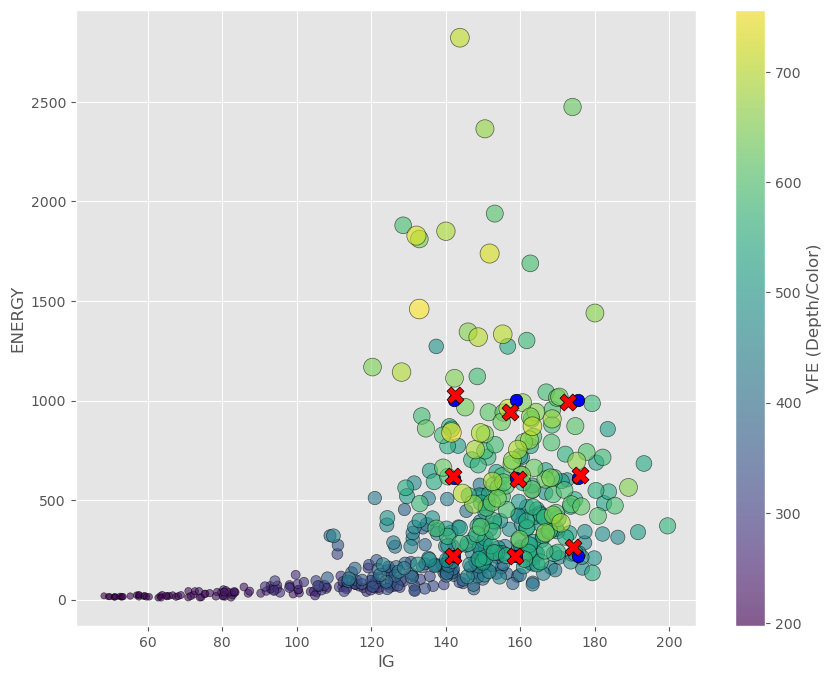

In [51]:
viz = ResearchVisualizer(df)

# --- 例: IG vs Energy のランドスケープにPSO結果を重ねる ---
fig, ax = plt.subplots(figsize=(10, 8))

viz.plot_landscape(ax=ax, x='ig', y='energy', z='vfe') # ベース
viz.add_pso_results(ax, df_pso)                      # PSOレイヤー
# viz.finalize(ax, title="Optimization Analysis", save_path="results/opt_analysis.png")

In [52]:
# igを6段階、それぞれエネルギー最小化

# Energy (エネルギー)の値をリスト化
energy_min_range = df['energy'].quantile(0.05)
energy_max_range = df['energy'].quantile(0.95)
energy_low = df['energy'].quantile(0.50)
energy_high = df['energy'].quantile(0.95)
energy_middle = (energy_low + energy_high)/2

energy_target_value_list: Dict[str, float] = {
    "L": energy_low, 
    "M": energy_middle, 
    "H": energy_high, 
    "min": energy_min_range, 
    "max": energy_max_range 
}

# igの値をリスト化
ig_min_range = df['ig'].quantile(0.05)
ig_max_range = df['ig'].quantile(0.95)
ig_thresholds_array = np.linspace(ig_min_range, ig_max_range, num=6)

# 6点に対する名前と値の辞書を作成 (L1, L2, ..., L6)
ig_target_value_list_6point: Dict[str, float] = {}

for i in range(6):
    # L1, L2, L3, L4, L5, L6 のキーを作成
    key = f"L{i+1}"
    ig_target_value_list_6point[key] = ig_thresholds_array[i]

# 元の min, max も含めておく
ig_target_value_list_6point["min"] = ig_min_range
ig_target_value_list_6point["max"] = ig_max_range

# opt.dof は環境依存のため、ここでは仮の値 (Optimizerクラスのdof属性を使用することを想定)
dof = opt.agent.dof # 実行環境に合わせて変更してください (例: opt.dof) 
targets_list_ig6: Dict[str, Dict[str, Any]] = {}

IG_LEVELS = ['L1', 'L2', 'L3', 'L4', 'L5', 'L6']


# igのレベルとインデックスを同時に取得
for i, ig_level in enumerate(IG_LEVELS):
    # igのターゲット値を取得 (L1-L6)
    ig_target_value = ig_target_value_list_6point[ig_level]

    # target_id の生成: dofX_S{VFE}_IG{IG}
    target_id = f"dof{dof}_IG{ig_level}_Emin"
    
    # ターゲット辞書の構築
    targets = {
        "ig": {
            "target": ig_target_value, 
            "min": ig_target_value_list_6point["min"], 
            "max": ig_target_value_list_6point["max"]
        },
        "energy": {
            "target": 0.0,
            "min": energy_target_value_list["min"],
            "max": energy_target_value_list["max"]
        },
    }
    targets_list_ig6[target_id] = targets

# 結果の確認（6通りの組み合わせが生成されていることを確認）
print(f"生成されたターゲットの総数: {len(targets_list_LVFE)}")

# visualize_json(targets_list_LVFE)


# JSONファイルとして保存
ig_emin_path = sim_dir/"stimuli/ig_emin/"
os.makedirs(ig_emin_path, exist_ok=True)
with open(ig_emin_path/"target.json", 'w', encoding='utf-8') as f:
    json.dump(targets_list_ig6, f, indent=4)

生成されたターゲットの総数: 6


In [ ]:

ig_emin_dir = ig_emin_path

pso_iters = 1
n_particles = 491
ftol = 1e-5
ftol_iter = 5
compensate_grav = False
switch_cost_threshold = 1e-3
scipy_maxiter = 100


weight = {
    "ig": 1.0,
    "energy": 0.001
}

iter = 491 # 先行研究では491?(varの間隔が0.001)

varmin = 0.01 * (2*np.pi) # 先刻研究通りなら0.01(ただし制御点は0~1の値域であったので、ここでは関節角度にスケールするべきか)
varmax = 0.5 * (2*np.pi) # 先刻研究通りなら0.5(ただし制御点は0~1の値域であったので、ここでは関節角度にスケールするべきか)

n_divisions = iter
var_list = np.linspace(varmin, varmax, n_divisions, endpoint=True)

particle_hist = []
for i in range(iter):
    start_time = time.time()

    # ランダムな動きを生成し、環境に設定
    # qs = random_qs_spline(model, time_steps, start, end, seed=i, num_knots=num_knots)
    # opt.env.computeAllobs(qs, dt)

    # もととなる動きにノイズを加える形で生成するバージョン
    var = var_list[i]
    qs, particle= random_qs_from_base(opt.model, opt.timesteps, 
                                   opt.start, opt.end, 
                                   base_particle=base_particle, 
                                   var=var, limits=opt.limits, seed=i, 
                                   type="B-spline", 
                                #    grad1=True, grad2=True, grad3=True,
                                   particle_return=True)
    # opt.env.computeAllobs(qs, dt)

    particle_hist.append(particle)
    

# base_particle = opt.const_beliefs_result.best_particle
# dimensions= len(base_particle)
# noise_range = np.pi
# noise = np.random.normal(
#     loc=0,
#     scale=noise_range,
#     size=(n_particles, dimensions)
# )
# initial_pos = base_particle[None, :] + noise

# landscapeの最後尾から初期位置を取得
base_particle = opt.const_beliefs_result.best_particle
dimensions = len(base_particle)
last_n_particles = particle_hist[-n_particles:]
# 2. 取得した Particle オブジェクトから、それぞれの「位置情報 (.pos)」のみを抽出する
#    この結果は、リストのリスト、またはNumPy配列のリストになる
initial_pos_list = [p for p in last_n_particles]

# 3. リストをNumPy配列に変換し、PSOが期待する (n_particles, dimensions) の形状に確定させる
#    ※ p.pos が既に (dimensions,) の形状であれば、np.array()で自動的に正しい2次元形状になります。
initial_pos = np.array(initial_pos_list)

for stim_id, target in targets_list_ig6.items():
    print(f"[{stim_id}]generating...")

    result = opt.hybrid_optimize(
        targets=target,
        weight=weight,
        norm="L2",
        pso_iters=pso_iters,             # PSOの最大イテレーション
        n_particles=n_particles, 
        scipy_maxiter=scipy_maxiter,           # Scipyの最大反復
        ftol=ftol, 
        ftol_iter=ftol_iter,
        compensate_grav=compensate_grav,
        initial_pos=initial_pos, # ウォームスタート
        switch_cost_threshold=switch_cost_threshold
        )
    
    # 結果の保存
    result.save(ig_emin_dir, f"{stim_id}.pkl")
    plot_robot_motion(result, folder_path=ig_emin_dir, file_name=f"{stim_id}.mp4")



In [ ]:

def stimuli_to_target_df(targets_list, folder_path):
    rows = []
    
    for target_id, targets in targets_list.items():
        try:
            # 1. ファイルの読み込み
            # target_id が 'stimuli_001' なら 'stimuli_001.pkl' を探す
            file_name = target_id if target_id.endswith('.pkl') else f"{target_id}.pkl"
            full_path = os.path.join(folder_path, file_name)
            
            if not os.path.exists(full_path):
                print(f"Skip: {full_path} does not exist.")
                continue

            with open(full_path, 'rb') as f:
                # クラス定義が読み込み環境にある前提
                result = pickle.load(f) 
            
            # 2. データの抽出
            metrics = result.final_metrics
            summary = result.optimization_summary
            
            # 1行分のデータを作成
            row = {
                'target_id': target_id,
                # --- PSOが到達した結果 (Achieved) ---
                'ig': metrics.get('ig'),
                'energy': metrics.get('energy'),
                'vfe': metrics.get('vfe'),
                
                # --- 目標としていた値 (Target) ---
                'target_ig': targets.get('ig', {}).get('target'),
                'target_energy': targets.get('energy', {}).get('target'),
                'target_vfe': targets.get('vfe', {}).get('target'),
                
                # --- 分析に役立つ付加情報 ---
                'success': summary.get('success'),
                'nit': summary.get('nit', summary.get('n_actual_iterations')), # PSO/Scipy両対応
                'best_cost': result.best_cost,
                'robot_model': result.robot_model_key,
                'optimizer': result.optimizer_type
            }
            rows.append(row)
            
        except Exception as e:
            print(f"Error loading {target_id}: {e}")
            continue
            
    # 全ての行をまとめて DataFrame に変換
    return pd.DataFrame(rows)


df_pso = stimuli_to_target_df(targets_list_ig6, sim_dir/"stimuli/ig_emin")
# 統合
viz = ResearchVisualizer(df)
fig, ax = plt.subplots(figsize=(10, 7))

viz.plot_landscape(ax=ax) # 背景の散布図
# plot_pareto_on_landscape(viz, ax, df_pso) 
viz.add_pso_results(ax, df_pso)
viz.finalize(ax, title="System Performance Limit: IG vs Energy")
plt.show()

In [ ]:

ids_to_refine = ["dof2_IGL1_Emin", "dof2_IGL2_Emin"]

targets_list_ig6_refined = {
    _id: targets_list_ig6[_id] 
    for _id in ids_to_refine 
    if _id in targets_list_ig6 # 念のためキーの存在を確認
}



ig_emin_dir = ig_emin_path

pso_iters = 1
n_particles = 491
ftol = 1e-5
ftol_iter = 5
compensate_grav = False
switch_cost_threshold = 1e-4
scipy_maxiter = 100


weight = {
    "ig": 100.0,
    "energy": 0.0001
}

iter = 491 # 先行研究では491?(varの間隔が0.001)

varmin = 0.01 * (2*np.pi) # 先刻研究通りなら0.01(ただし制御点は0~1の値域であったので、ここでは関節角度にスケールするべきか)
varmax = 0.5 * (2*np.pi) # 先刻研究通りなら0.5(ただし制御点は0~1の値域であったので、ここでは関節角度にスケールするべきか)

n_divisions = iter
var_list = np.linspace(varmin, varmax, n_divisions, endpoint=True)

particle_hist = []
for i in range(iter):
    start_time = time.time()

    # ランダムな動きを生成し、環境に設定
    # qs = random_qs_spline(model, time_steps, start, end, seed=i, num_knots=num_knots)
    # opt.env.computeAllobs(qs, dt)

    # もととなる動きにノイズを加える形で生成するバージョン
    var = var_list[i]
    qs, particle= random_qs_from_base(opt.model, opt.timesteps, 
                                   opt.start, opt.end, 
                                   base_particle=base_particle, 
                                   var=var, limits=opt.limits, seed=i, 
                                   type="B-spline", 
                                #    grad1=True, grad2=True, grad3=True,
                                   particle_return=True)
    # opt.env.computeAllobs(qs, dt)

    particle_hist.append(particle)
    

# base_particle = opt.const_beliefs_result.best_particle
# dimensions= len(base_particle)
# noise_range = np.pi
# noise = np.random.normal(
#     loc=0,
#     scale=noise_range,
#     size=(n_particles, dimensions)
# )
# initial_pos = base_particle[None, :] + noise

# landscapeの最後尾から初期位置を取得
base_particle = opt.const_beliefs_result.best_particle
dimensions = len(base_particle)
# last_n_particles = particle_hist[-n_particles:]

last_n_particles = particle_hist[:n_particles]

# 2. 取得した Particle オブジェクトから、それぞれの「位置情報 (.pos)」のみを抽出する
#    この結果は、リストのリスト、またはNumPy配列のリストになる
initial_pos_list = [p for p in last_n_particles]

# 3. リストをNumPy配列に変換し、PSOが期待する (n_particles, dimensions) の形状に確定させる
#    ※ p.pos が既に (dimensions,) の形状であれば、np.array()で自動的に正しい2次元形状になります。
initial_pos = np.array(initial_pos_list)

for stim_id, target in targets_list_ig6_refined.items():
    print(f"[{stim_id}]generating...")

    result = opt.hybrid_optimize(
        targets=target,
        weight=weight,
        norm="L2",
        pso_iters=pso_iters,             # PSOの最大イテレーション
        n_particles=n_particles, 
        scipy_maxiter=scipy_maxiter,           # Scipyの最大反復
        ftol=ftol, 
        ftol_iter=ftol_iter,
        compensate_grav=compensate_grav,
        initial_pos=initial_pos, # ウォームスタート
        switch_cost_threshold=switch_cost_threshold
        )
    
    # 結果の保存
    result.save(ig_emin_dir, f"{stim_id}.pkl")
    plot_robot_motion(result, folder_path=ig_emin_dir, file_name=f"{stim_id}.mp4")


In [ ]:
from sim_utils import *

df_pso = stimuli_to_target_df(targets_list_ig6, sim_dir/"stimuli/ig_emin", ext=".pkl")
# 統合
viz = ResearchVisualizer(df)
fig, ax = plt.subplots(figsize=(10, 7))

viz.plot_landscape(ax=ax) # 背景の散布図
# plot_pareto_on_landscape(viz, ax, df_pso) 
viz.add_pso_results(ax, df_pso)
viz.finalize(ax, title="System Performance Limit: IG vs Energy", save_path=sim_dir/"stimuli/ig_emin")
plt.show()

ax = viz.plot_landscape(x="ig", y="vfe")
viz.add_pso_results(ax, df_pso, x="ig", y="vfe")
viz.finalize(ax, title="System Performance Limit: IG vs Energy", save_path=sim_dir/"stimuli/ig_emin")
plt.show()

パレト曲線を作成

In [ ]:
# パレト曲線を描く
pareto_dir = sim_dir/"pareto"

pso_iters = 1
n_particles = 100
ftol = 1e-5
ftol_iter = 5
compensate_grav = False

scipy_maxiter = 100

range_config = targets_list_LE["dof2_EH_IGH"]


base_particle = opt.const_beliefs_result.best_particle
dimensions= len(base_particle)
noise_range = np.pi
noise = np.random.normal(
    loc=0,
    scale=noise_range,
    size=(n_particles, dimensions)
)
initial_pos = base_particle[None, :] + noise

def generate_hybrid_pareto_sweep(save_dir, target_config, steps=11, switch_cost_threshold=5e-4):
    """
    Hybrid Optimize（PSO + L-BFGS-B）を用いてパレト曲線を得る。
    αを変化させ、前ステップの最適解を次ステップの初期値（ウォームスタート）として利用する。
    """
    import os
    os.makedirs(save_dir, exist_ok=True)

    # 1. ターゲット設定の共通化
    # 目的：IGをmaxに、Energyを0.0に近づける（正規化範囲内で評価）
    pso_targets = {
        'ig': {'target': target_config['ig']['max'], 'min': target_config['ig']['min'], 'max': target_config['ig']['max']},
        'energy': {'target': 0.0, 'min': target_config['energy']['min'], 'max': target_config['energy']['max']},
        'vfe': {'target': 0.0, 'min': 0.0, 'max': 1000.0} # VFEのレンジは目安
    }
    
    pareto_results = []
    alphas = np.linspace(0.0, 1.0, steps) # 0.0 (Energy重視) -> 1.0 (IG重視)
    
    # --- 初期の粒子群（initial_pos）の準備 ---
    # 初回（i=0）のみ、ユーザー指定のノイズ付き初期位置を使用
    current_initial_pos = initial_pos 

    for i, alpha in enumerate(alphas):
        # 2. 重みの設計
        current_weight = {
            "ig": float(alpha),
            "energy": float(1.0 - alpha),
            "vfe": 1.0 
        }
        
        run_id = f"hybrid_pareto_alpha_{alpha:.2f}"
        print(f"\n[{i+1}/{steps}] Sweep Alpha: {alpha:.2f} (IG: {alpha:.2f}, Energy: {1.0-alpha:.2f})")
        
        # 3. ハイブリッド最適化実行
        # pso_optimize ではなく hybrid_optimize を呼び出す
        result = opt.hybrid_optimize(
            targets=pso_targets,
            weight=current_weight,
            norm="L2",
            pso_iters=pso_iters,             # PSOの最大イテレーション
            n_particles=n_particles, 
            scipy_maxiter=scipy_maxiter,           # Scipyの最大反復
            ftol=ftol, 
            ftol_iter=ftol_iter,
            compensate_grav=compensate_grav,
            initial_pos=current_initial_pos, # ウォームスタート
            switch_cost_threshold=switch_cost_threshold
        )
        
        # 4. 次のステップへのバトンタッチ（ウォームスタートの準備）
        # 今回の「最高の結果」を次のステップの全粒子の中心にする
        # これにより、パレト曲線が滑らかに繋がる
        best_particle = result.best_particle
        current_initial_pos = best_particle[None, :] + np.random.normal(0, 0.05, size=(n_particles, dimensions))

        # 5. 指標とプロセス情報の抽出
        metrics = result.final_metrics
        summary = result.optimization_summary
        
        pareto_results.append({
            'alpha': alpha,
            'ig': metrics['ig'],
            'energy': metrics['energy'],
            'vfe': metrics['vfe'],
            'jerk': metrics['jerk'],
            'best_cost': result.best_cost,
            'switched_by': result.optimizer_params['switched_by'],
            'pso_actual_iters': result.optimizer_params['pso_actual_iters'],
            'scipy_actual_nit': result.optimizer_params['scipy_actual_nit'],
            'success': summary.get('success', False)
        })
        
        # 結果の保存
        result.save(save_dir, f"{run_id}.pkl")
        
    return pd.DataFrame(pareto_results)

# 実行
# switch_cost_thresholdは、PSOからScipyへ切り替えるタイミングを調整するパラメータです。
df_hybrid_pareto = generate_hybrid_pareto_sweep(pareto_dir, range_config, steps=11)



def plot_pareto_on_landscape(viz, ax, df_pareto):
    # IGの昇順でソート（線が綺麗に繋がるように）
    df_sorted = df_pareto.sort_values('ig')
    
    # 1. パレトラインの描画
    ax.plot(df_sorted['ig'], df_sorted['energy'], 'o-', 
            color='gray', linewidth=3, markersize=8, 
            label='Pareto Frontier (Weight Sweep)', zorder=30)
    
    # 2. 端点のラベル付け
    ax.text(df_sorted['ig'].iloc[0], df_sorted['energy'].iloc[0], '  Energy-Min (alpha=0)', 
            color='black', va='center', fontweight='bold')
    ax.text(df_sorted['ig'].iloc[-1], df_sorted['energy'].iloc[-1], '  IG-Max (alpha=1)', 
            color='black', va='center', fontweight='bold')
    
    return ax


# 統合
viz = ResearchVisualizer(df)
fig, ax = plt.subplots(figsize=(10, 7))
viz.plot_landscape(ax=ax) # 背景の散布図
plot_pareto_on_landscape(viz, ax, df_hybrid_pareto) # パレト曲線
viz.finalize(ax, title="System Performance Limit: IG vs Energy")
plt.show()



[1/11] Sweep Alpha: 0.00 (IG: 0.00, Energy: 1.00)
Phase 1: PSO (Max 1 iters, Switch Threshold: 5.00e-04)


KeyboardInterrupt: 

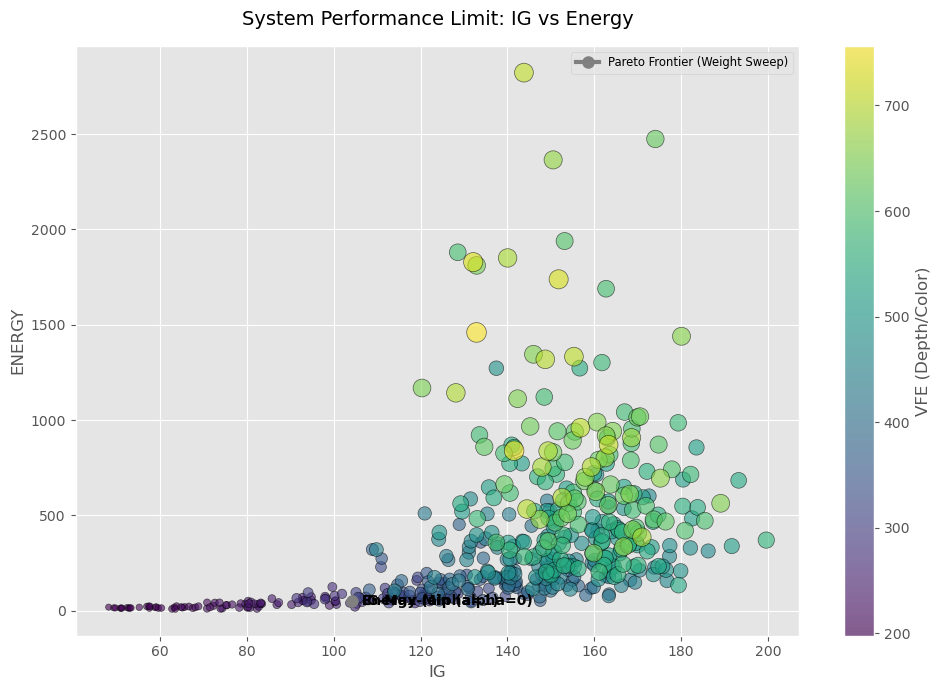

In [ ]:



def plot_pareto_on_landscape(viz, ax, df_pareto):
    # IGの昇順でソート（線が綺麗に繋がるように）
    df_sorted = df_pareto.sort_values('ig')
    
    # 1. パレトラインの描画
    ax.plot(df_sorted['ig'], df_sorted['energy'], 'o-', 
            color='gray', linewidth=3, markersize=8, 
            label='Pareto Frontier (Weight Sweep)', zorder=30)
    
    # 2. 端点のラベル付け
    ax.text(df_sorted['ig'].iloc[0], df_sorted['energy'].iloc[0], '  Energy-Min (alpha=0)', 
            color='black', va='center', fontweight='bold')
    ax.text(df_sorted['ig'].iloc[-1], df_sorted['energy'].iloc[-1], '  IG-Max (alpha=1)', 
            color='black', va='center', fontweight='bold')
    
    return ax



# 統合
viz = ResearchVisualizer(df)
fig, ax = plt.subplots(figsize=(10, 7))
viz.plot_landscape(ax=ax) # 背景の散布図
plot_pareto_on_landscape(viz, ax, df_hybrid_pareto) # パレト曲線
viz.finalize(ax, title="System Performance Limit: IG vs Energy")
plt.show()


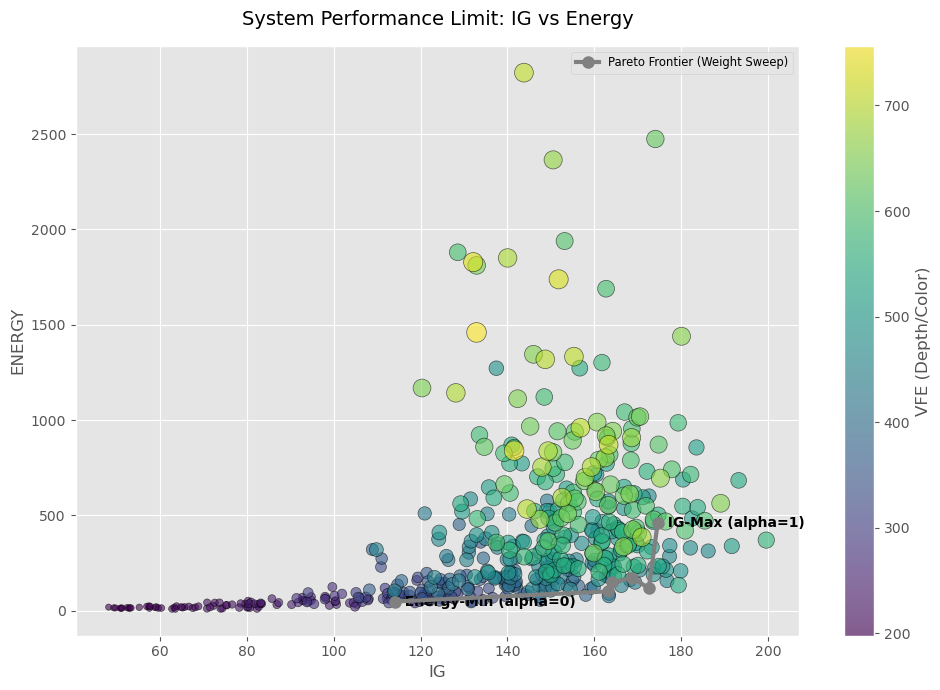

In [ ]:
def plot_pareto_on_landscape(viz, ax, df_pareto):
    # IGの昇順でソート（線が綺麗に繋がるように）
    df_sorted = df_pareto.sort_values('ig')
    
    # 1. パレトラインの描画
    ax.plot(df_sorted['ig'], df_sorted['energy'], 'o-', 
            color='gray', linewidth=3, markersize=8, 
            label='Pareto Frontier (Weight Sweep)', zorder=30)
    
    # 2. 端点のラベル付け
    ax.text(df_sorted['ig'].iloc[0], df_sorted['energy'].iloc[0], '  Energy-Min (alpha=0)', 
            color='black', va='center', fontweight='bold')
    ax.text(df_sorted['ig'].iloc[-1], df_sorted['energy'].iloc[-1], '  IG-Max (alpha=1)', 
            color='black', va='center', fontweight='bold')
    
    return ax



# 統合
viz = ResearchVisualizer(df)
fig, ax = plt.subplots(figsize=(10, 7))
viz.plot_landscape(ax=ax) # 背景の散布図
plot_pareto_on_landscape(viz, ax, df_pareto_sweep) # パレト曲線
viz.finalize(ax, title="System Performance Limit: IG vs Energy")
plt.show()

In [12]:
# igを6段階、それぞれエネルギー最小化

# Energy (エネルギー)の値をリスト化
energy_min_range = df['energy'].quantile(0.05)
energy_max_range = df['energy'].quantile(0.95)
energy_low = df['energy'].quantile(0.50)
energy_high = df['energy'].quantile(0.95)
energy_middle = (energy_low + energy_high)/2

energy_target_value_list: Dict[str, float] = {
    "L": energy_low, 
    "M": energy_middle, 
    "H": energy_high, 
    "min": energy_min_range, 
    "max": energy_max_range 
}

# igの値をリスト化
ig_min_range = df['ig'].quantile(0.05)
ig_max_range = df['ig'].quantile(0.95)
ig_thresholds_array = np.linspace(ig_min_range, ig_max_range, num=6)

# 6点に対する名前と値の辞書を作成 (L1, L2, ..., L6)
ig_target_value_list_6point: Dict[str, float] = {}

for i in range(6):
    # L1, L2, L3, L4, L5, L6 のキーを作成
    key = f"L{i+1}"
    ig_target_value_list_6point[key] = ig_thresholds_array[i]

# 元の min, max も含めておく
ig_target_value_list_6point["min"] = ig_min_range
ig_target_value_list_6point["max"] = ig_max_range

# opt.dof は環境依存のため、ここでは仮の値 (Optimizerクラスのdof属性を使用することを想定)
dof = opt.agent.dof # 実行環境に合わせて変更してください (例: opt.dof) 
targets_list_ig6: Dict[str, Dict[str, Any]] = {}

IG_LEVELS = ['L1', 'L2', 'L3', 'L4', 'L5', 'L6']


# igのレベルとインデックスを同時に取得
for i, ig_level in enumerate(IG_LEVELS):
    # igのターゲット値を取得 (L1-L6)
    ig_target_value = ig_target_value_list_6point[ig_level]

    # target_id の生成: dofX_S{VFE}_IG{IG}
    target_id = f"dof{dof}_IG{ig_level}_Emin"
    
    # ターゲット辞書の構築
    targets = {
        "ig": {
            "target": ig_target_value, 
            "min": ig_target_value_list_6point["min"], 
            "max": ig_target_value_list_6point["max"]
        },
        "energy": {
            "target": 0.0,
            "min": energy_target_value_list["min"],
            "max": energy_target_value_list["max"]
        },
    }
    targets_list_ig6[target_id] = targets

# 結果の確認（6通りの組み合わせが生成されていることを確認）
print(f"生成されたターゲットの総数: {len(targets_list_LVFE)}")

# visualize_json(targets_list_LVFE)


# JSONファイルとして保存
ig_emin_path = sim_dir/"stimuli/ig_emin/"
os.makedirs(ig_emin_path, exist_ok=True)
with open(ig_emin_path/"target.json", 'w', encoding='utf-8') as f:
    json.dump(targets_list_ig6, f, indent=4)

生成されたターゲットの総数: 6


In [ ]:
raw_data.keys()

dict_keys(['energy', 'jerk', 'torque_change', 'vfe', 'kld', 'bs', 'un', 'qs'])

In [ ]:

ig_emin_dir = ig_emin_path

pso_iters = 1
n_particles = 491
ftol = 1e-5
ftol_iter = 5
compensate_grav = False
switch_cost_threshold = 1e-3
scipy_maxiter = 100


weight = {
    "ig": 1.0,
    "energy": 0.001
}

iter = 491 # 先行研究では491?(varの間隔が0.001)

varmin = 0.01 * (2*np.pi) # 先刻研究通りなら0.01(ただし制御点は0~1の値域であったので、ここでは関節角度にスケールするべきか)
varmax = 0.5 * (2*np.pi) # 先刻研究通りなら0.5(ただし制御点は0~1の値域であったので、ここでは関節角度にスケールするべきか)

n_divisions = iter
var_list = np.linspace(varmin, varmax, n_divisions, endpoint=True)

particle_hist = []
for i in range(iter):
    start_time = time.time()

    # ランダムな動きを生成し、環境に設定
    # qs = random_qs_spline(model, time_steps, start, end, seed=i, num_knots=num_knots)
    # opt.env.computeAllobs(qs, dt)

    # もととなる動きにノイズを加える形で生成するバージョン
    var = var_list[i]
    qs, particle= random_qs_from_base(opt.model, opt.timesteps, 
                                   opt.start, opt.end, 
                                   base_particle=base_particle, 
                                   var=var, limits=opt.limits, seed=i, 
                                   type="B-spline", 
                                #    grad1=True, grad2=True, grad3=True,
                                   particle_return=True)
    # opt.env.computeAllobs(qs, dt)

    particle_hist.append(particle)
    

# base_particle = opt.const_beliefs_result.best_particle
# dimensions= len(base_particle)
# noise_range = np.pi
# noise = np.random.normal(
#     loc=0,
#     scale=noise_range,
#     size=(n_particles, dimensions)
# )
# initial_pos = base_particle[None, :] + noise

# landscapeの最後尾から初期位置を取得
base_particle = opt.const_beliefs_result.best_particle
dimensions = len(base_particle)
last_n_particles = particle_hist[-n_particles:]
# 2. 取得した Particle オブジェクトから、それぞれの「位置情報 (.pos)」のみを抽出する
#    この結果は、リストのリスト、またはNumPy配列のリストになる
initial_pos_list = [p for p in last_n_particles]

# 3. リストをNumPy配列に変換し、PSOが期待する (n_particles, dimensions) の形状に確定させる
#    ※ p.pos が既に (dimensions,) の形状であれば、np.array()で自動的に正しい2次元形状になります。
initial_pos = np.array(initial_pos_list)

for stim_id, target in targets_list_ig6.items():
    print(f"[{stim_id}]generating...")

    result = opt.hybrid_optimize(
        targets=target,
        weight=weight,
        norm="L2",
        pso_iters=pso_iters,             # PSOの最大イテレーション
        n_particles=n_particles, 
        scipy_maxiter=scipy_maxiter,           # Scipyの最大反復
        ftol=ftol, 
        ftol_iter=ftol_iter,
        compensate_grav=compensate_grav,
        initial_pos=initial_pos, # ウォームスタート
        switch_cost_threshold=switch_cost_threshold
        )
    
    # 結果の保存
    result.save(ig_emin_dir, f"{stim_id}.pkl")
    plot_robot_motion(result, folder_path=ig_emin_dir, file_name=f"{stim_id}.mp4")



[dof2_IGL1_Emin]generating...
Phase 1: PSO (Max 1 iters, Switch Threshold: 1.00e-03)
PSO: 100%|████████████████████| 1/1, best_cost=3.2646e-02
Phase 2: Scipy L-BFGS-B (Max 100 iters)


2025-12-19 10:52:29,283 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2025-12-19 10:52:29,285 - matplotlib.animation - INFO - MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 640x480 -pix_fmt rgba -framerate 30 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/rikut/py_venvs/my_sim_project/results/sim_dof2_20251215_213121/stimuli/ig_emin/dof2_IGL1_Emin.mp4


Hybrid Optimization Completed. Final Cost: 3.264606e-02
Success: Optimization result saved to dof2_IGL1_Emin.pkl and summary to dof2_IGL1_Emin.txt
Saving animation as '/home/rikut/py_venvs/my_sim_project/results/sim_dof2_20251215_213121/stimuli/ig_emin/dof2_IGL1_Emin.mp4'...
Saved successfully.
[dof2_IGL2_Emin]generating...
Phase 1: PSO (Max 1 iters, Switch Threshold: 1.00e-03)
PSO: 100%|████████████████████| 1/1, best_cost=4.4060e-03
Phase 2: Scipy L-BFGS-B (Max 100 iters)


2025-12-19 11:04:30,493 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2025-12-19 11:04:30,495 - matplotlib.animation - INFO - MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 640x480 -pix_fmt rgba -framerate 30 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/rikut/py_venvs/my_sim_project/results/sim_dof2_20251215_213121/stimuli/ig_emin/dof2_IGL2_Emin.mp4


Hybrid Optimization Completed. Final Cost: 4.406042e-03
Success: Optimization result saved to dof2_IGL2_Emin.pkl and summary to dof2_IGL2_Emin.txt
Saving animation as '/home/rikut/py_venvs/my_sim_project/results/sim_dof2_20251215_213121/stimuli/ig_emin/dof2_IGL2_Emin.mp4'...
Saved successfully.
[dof2_IGL3_Emin]generating...
Phase 1: PSO (Max 1 iters, Switch Threshold: 1.00e-03)
PSO: 100%|████████████████████| 1/1, best_cost=1.2827e-05
[Switch] Cost 1.2827e-05 < 1.00e-03. Switching to Scipy.

Phase 2: Scipy L-BFGS-B (Max 100 iters)


...

Hybrid Optimization Completed. Final Cost: 9.460423e-06
Success: Optimization result saved to dof2_IGL4_Emin.pkl and summary to dof2_IGL4_Emin.txt
Saving animation as '/home/rikut/py_venvs/my_sim_project/results/sim_dof2_20251215_213121/stimuli/ig_emin/dof2_IGL4_Emin.mp4'...
Saved successfully.
[dof2_IGL5_Emin]generating...
Phase 1: PSO (Max 1 iters, Switch Threshold: 1.00e-03)
PSO: 100%|████████████████████| 1/1, best_cost=1.0089e-05
[Switch] Cost 1.0089e-05 < 1.00e-03. Switching to Scipy.

Phase 2: Scipy L-BFGS-B (Max 100 iters)


2025-12-19 11:39:41,653 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2025-12-19 11:39:41,654 - matplotlib.animation - INFO - MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 640x480 -pix_fmt rgba -framerate 30 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/rikut/py_venvs/my_sim_project/results/sim_dof2_20251215_213121/stimuli/ig_emin/dof2_IGL5_Emin.mp4


Hybrid Optimization Completed. Final Cost: 1.008800e-05
Success: Optimization result saved to dof2_IGL5_Emin.pkl and summary to dof2_IGL5_Emin.txt
Saving animation as '/home/rikut/py_venvs/my_sim_project/results/sim_dof2_20251215_213121/stimuli/ig_emin/dof2_IGL5_Emin.mp4'...
Saved successfully.
[dof2_IGL6_Emin]generating...
Phase 1: PSO (Max 1 iters, Switch Threshold: 1.00e-03)
PSO: 100%|████████████████████| 1/1, best_cost=3.7880e-04
[Switch] Cost 3.7880e-04 < 1.00e-03. Switching to Scipy.

Phase 2: Scipy L-BFGS-B (Max 100 iters)


2025-12-19 11:51:34,257 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2025-12-19 11:51:34,258 - matplotlib.animation - INFO - MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 640x480 -pix_fmt rgba -framerate 30 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/rikut/py_venvs/my_sim_project/results/sim_dof2_20251215_213121/stimuli/ig_emin/dof2_IGL6_Emin.mp4


Hybrid Optimization Completed. Final Cost: 3.787911e-04
Success: Optimization result saved to dof2_IGL6_Emin.pkl and summary to dof2_IGL6_Emin.txt
Saving animation as '/home/rikut/py_venvs/my_sim_project/results/sim_dof2_20251215_213121/stimuli/ig_emin/dof2_IGL6_Emin.mp4'...
Saved successfully.


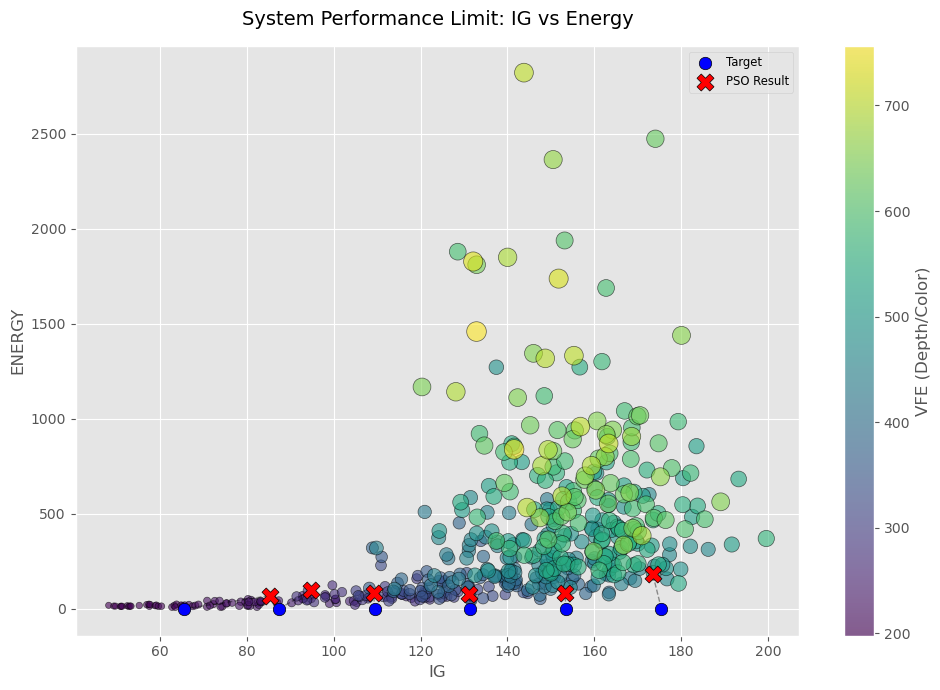

In [ ]:

def stimuli_to_target_df(targets_list, folder_path):
    rows = []
    
    for target_id, targets in targets_list.items():
        try:
            # 1. ファイルの読み込み
            # target_id が 'stimuli_001' なら 'stimuli_001.pkl' を探す
            file_name = target_id if target_id.endswith('.pkl') else f"{target_id}.pkl"
            full_path = os.path.join(folder_path, file_name)
            
            if not os.path.exists(full_path):
                print(f"Skip: {full_path} does not exist.")
                continue

            with open(full_path, 'rb') as f:
                # クラス定義が読み込み環境にある前提
                result = pickle.load(f) 
            
            # 2. データの抽出
            metrics = result.final_metrics
            summary = result.optimization_summary
            
            # 1行分のデータを作成
            row = {
                'target_id': target_id,
                # --- PSOが到達した結果 (Achieved) ---
                'ig': metrics.get('ig'),
                'energy': metrics.get('energy'),
                'vfe': metrics.get('vfe'),
                
                # --- 目標としていた値 (Target) ---
                'target_ig': targets.get('ig', {}).get('target'),
                'target_energy': targets.get('energy', {}).get('target'),
                'target_vfe': targets.get('vfe', {}).get('target'),
                
                # --- 分析に役立つ付加情報 ---
                'success': summary.get('success'),
                'nit': summary.get('nit', summary.get('n_actual_iterations')), # PSO/Scipy両対応
                'best_cost': result.best_cost,
                'robot_model': result.robot_model_key,
                'optimizer': result.optimizer_type
            }
            rows.append(row)
            
        except Exception as e:
            print(f"Error loading {target_id}: {e}")
            continue
            
    # 全ての行をまとめて DataFrame に変換
    return pd.DataFrame(rows)


df_pso = stimuli_to_target_df(targets_list_ig6, sim_dir/"stimuli/ig_emin")
# 統合
viz = ResearchVisualizer(df)
fig, ax = plt.subplots(figsize=(10, 7))

viz.plot_landscape(ax=ax) # 背景の散布図
# plot_pareto_on_landscape(viz, ax, df_pso) 
viz.add_pso_results(ax, df_pso)
viz.finalize(ax, title="System Performance Limit: IG vs Energy")
plt.show()

In [ ]:

ids_to_refine = ["dof2_IGL1_Emin", "dof2_IGL2_Emin"]

targets_list_ig6_refined = {
    _id: targets_list_ig6[_id] 
    for _id in ids_to_refine 
    if _id in targets_list_ig6 # 念のためキーの存在を確認
}



ig_emin_dir = ig_emin_path

pso_iters = 1
n_particles = 491
ftol = 1e-5
ftol_iter = 5
compensate_grav = False
switch_cost_threshold = 1e-4
scipy_maxiter = 100


weight = {
    "ig": 100.0,
    "energy": 0.0001
}

iter = 491 # 先行研究では491?(varの間隔が0.001)

varmin = 0.01 * (2*np.pi) # 先刻研究通りなら0.01(ただし制御点は0~1の値域であったので、ここでは関節角度にスケールするべきか)
varmax = 0.5 * (2*np.pi) # 先刻研究通りなら0.5(ただし制御点は0~1の値域であったので、ここでは関節角度にスケールするべきか)

n_divisions = iter
var_list = np.linspace(varmin, varmax, n_divisions, endpoint=True)

particle_hist = []
for i in range(iter):
    start_time = time.time()

    # ランダムな動きを生成し、環境に設定
    # qs = random_qs_spline(model, time_steps, start, end, seed=i, num_knots=num_knots)
    # opt.env.computeAllobs(qs, dt)

    # もととなる動きにノイズを加える形で生成するバージョン
    var = var_list[i]
    qs, particle= random_qs_from_base(opt.model, opt.timesteps, 
                                   opt.start, opt.end, 
                                   base_particle=base_particle, 
                                   var=var, limits=opt.limits, seed=i, 
                                   type="B-spline", 
                                #    grad1=True, grad2=True, grad3=True,
                                   particle_return=True)
    # opt.env.computeAllobs(qs, dt)

    particle_hist.append(particle)
    

# base_particle = opt.const_beliefs_result.best_particle
# dimensions= len(base_particle)
# noise_range = np.pi
# noise = np.random.normal(
#     loc=0,
#     scale=noise_range,
#     size=(n_particles, dimensions)
# )
# initial_pos = base_particle[None, :] + noise

# landscapeの最後尾から初期位置を取得
base_particle = opt.const_beliefs_result.best_particle
dimensions = len(base_particle)
# last_n_particles = particle_hist[-n_particles:]

last_n_particles = particle_hist[:n_particles]

# 2. 取得した Particle オブジェクトから、それぞれの「位置情報 (.pos)」のみを抽出する
#    この結果は、リストのリスト、またはNumPy配列のリストになる
initial_pos_list = [p for p in last_n_particles]

# 3. リストをNumPy配列に変換し、PSOが期待する (n_particles, dimensions) の形状に確定させる
#    ※ p.pos が既に (dimensions,) の形状であれば、np.array()で自動的に正しい2次元形状になります。
initial_pos = np.array(initial_pos_list)

for stim_id, target in targets_list_ig6_refined.items():
    print(f"[{stim_id}]generating...")

    result = opt.hybrid_optimize(
        targets=target,
        weight=weight,
        norm="L2",
        pso_iters=pso_iters,             # PSOの最大イテレーション
        n_particles=n_particles, 
        scipy_maxiter=scipy_maxiter,           # Scipyの最大反復
        ftol=ftol, 
        ftol_iter=ftol_iter,
        compensate_grav=compensate_grav,
        initial_pos=initial_pos, # ウォームスタート
        switch_cost_threshold=switch_cost_threshold
        )
    
    # 結果の保存
    result.save(ig_emin_dir, f"{stim_id}.pkl")
    plot_robot_motion(result, folder_path=ig_emin_dir, file_name=f"{stim_id}.mp4")


[dof2_IGL1_Emin]generating...
Phase 1: PSO (Max 1 iters, Switch Threshold: 1.00e-04)
PSO: 100%|████████████████████| 1/1, best_cost=3.2641e+00
Phase 2: Scipy L-BFGS-B (Max 100 iters)


2025-12-19 14:24:03,437 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2025-12-19 14:24:03,439 - matplotlib.animation - INFO - MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 640x480 -pix_fmt rgba -framerate 30 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/rikut/py_venvs/my_sim_project/results/sim_dof2_20251215_213121/stimuli/ig_emin/dof2_IGL1_Emin.mp4


Hybrid Optimization Completed. Final Cost: 3.264105e+00
Success: Optimization result saved to dof2_IGL1_Emin.pkl and summary to dof2_IGL1_Emin.txt
Saving animation as '/home/rikut/py_venvs/my_sim_project/results/sim_dof2_20251215_213121/stimuli/ig_emin/dof2_IGL1_Emin.mp4'...
Saved successfully.
[dof2_IGL2_Emin]generating...
Phase 1: PSO (Max 1 iters, Switch Threshold: 1.00e-04)
PSO: 100%|████████████████████| 1/1, best_cost=4.3958e-01
Phase 2: Scipy L-BFGS-B (Max 100 iters)


2025-12-19 14:35:38,828 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2025-12-19 14:35:38,829 - matplotlib.animation - INFO - MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 640x480 -pix_fmt rgba -framerate 30 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/rikut/py_venvs/my_sim_project/results/sim_dof2_20251215_213121/stimuli/ig_emin/dof2_IGL2_Emin.mp4


Hybrid Optimization Completed. Final Cost: 4.395795e-01
Success: Optimization result saved to dof2_IGL2_Emin.pkl and summary to dof2_IGL2_Emin.txt
Saving animation as '/home/rikut/py_venvs/my_sim_project/results/sim_dof2_20251215_213121/stimuli/ig_emin/dof2_IGL2_Emin.mp4'...
Saved successfully.


✅ Saved: /home/rikut/py_venvs/my_sim_project/results/sim_dof2_20251215_213121/stimuli/ig_emin


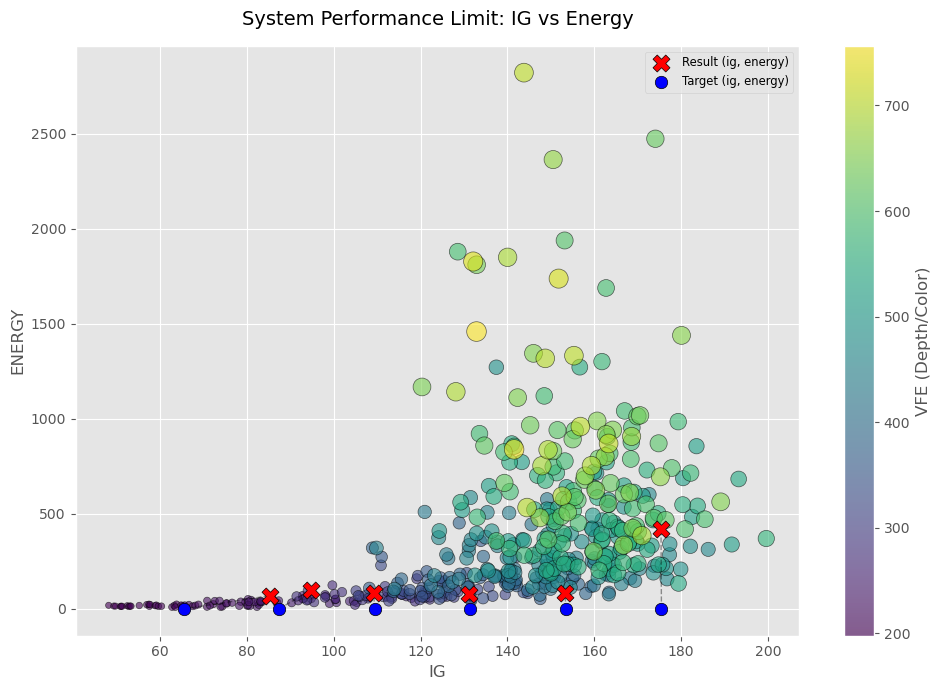

✅ Saved: /home/rikut/py_venvs/my_sim_project/results/sim_dof2_20251215_213121/stimuli/ig_emin


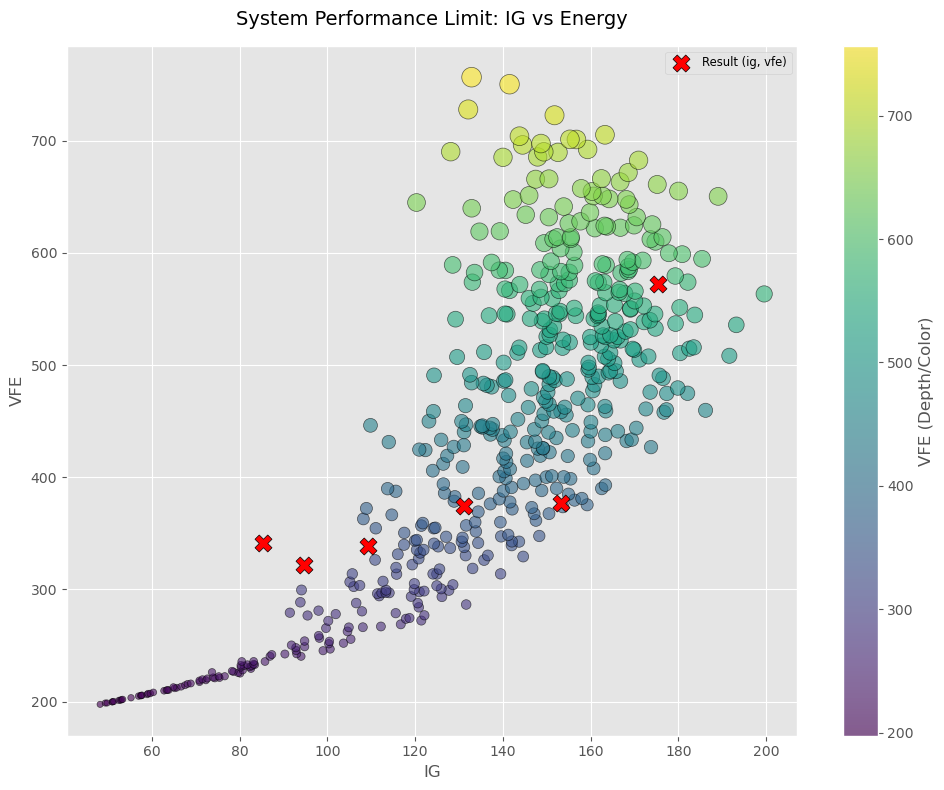

In [17]:
from sim_utils import *

df_pso = stimuli_to_target_df(targets_list_ig6, sim_dir/"stimuli/ig_emin", ext=".pkl")
# 統合
viz = ResearchVisualizer(df)
fig, ax = plt.subplots(figsize=(10, 7))

viz.plot_landscape(ax=ax) # 背景の散布図
# plot_pareto_on_landscape(viz, ax, df_pso) 
viz.add_pso_results(ax, df_pso)
viz.finalize(ax, title="System Performance Limit: IG vs Energy", save_path=sim_dir/"stimuli/ig_emin")
plt.show()

ax = viz.plot_landscape(x="ig", y="vfe")
viz.add_pso_results(ax, df_pso, x="ig", y="vfe")
viz.finalize(ax, title="System Performance Limit: IG vs Energy", save_path=sim_dir/"stimuli/ig_emin")
plt.show()

In [24]:
target_value = targets_list_ig6["dof2_IGL1_Emin"]["ig"]["target"]  # 例：5パーセンタイルの値
# 絶対値の差が最小のインデックスを取得
closest_idx = (df['ig'] - target_value).abs().idxmin()

# その行を抽出
closest_row = df.loc[closest_idx]

print(f"Target IG: {target_value}")
print(f"Found IG:  {closest_row['ig']}")
print(closest_row)

Target IG: 65.46400526538491
Found IG:  65.72053147852421
energy            19.499574
jerk             124.491648
torque_change    546.646645
vfe              212.461773
kld               40.630518
bs                25.090013
un               156.150770
ig                65.720531
Name: 8, dtype: float64


In [ ]:
qss[closest_idx]
plot_robot_motion()

array([[-1.11604664e+00, -1.01207936e+00],
       [-1.02620850e+00, -1.03270137e+00],
       [-9.42840631e-01, -1.04871827e+00],
       [-8.65691596e-01, -1.06036741e+00],
       [-7.94509958e-01, -1.06788614e+00],
       [-7.29044277e-01, -1.07151180e+00],
       [-6.69043116e-01, -1.07148174e+00],
       [-6.14255036e-01, -1.06803329e+00],
       [-5.64428600e-01, -1.06140381e+00],
       [-5.19312369e-01, -1.05183064e+00],
       [-4.78654904e-01, -1.03955112e+00],
       [-4.42204768e-01, -1.02480259e+00],
       [-4.09710523e-01, -1.00782241e+00],
       [-3.80920729e-01, -9.88847908e-01],
       [-3.55583950e-01, -9.68116438e-01],
       [-3.33448746e-01, -9.45865342e-01],
       [-3.14263679e-01, -9.22331964e-01],
       [-2.97777312e-01, -8.97753648e-01],
       [-2.83738206e-01, -8.72367738e-01],
       [-2.71894922e-01, -8.46411579e-01],
       [-2.61996023e-01, -8.20122516e-01],
       [-2.53790070e-01, -7.93737891e-01],
       [-2.47025625e-01, -7.67495051e-01],
       [-2.

In [20]:
df.head()

,energy,jerk,torque_change,vfe,kld,bs,un,ig
0,14.995091,152.615243,479.887756,201.701530,32.919406,20.205409,155.929085,53.124816
1,16.432963,158.688884,536.214433,201.182784,32.531832,19.980000,155.923045,52.511833
2,18.806020,131.791220,446.150955,197.638987,29.870921,18.355972,155.855360,48.226893
3,13.767399,213.314862,595.348334,200.222925,31.791792,19.543836,155.906059,51.335628
4,14.694024,137.974768,428.518926,198.868166,30.886193,18.920890,155.883513,49.807083
